# ML1: Tariff Recommendation

We have data on the behavior of customers who have already switched to one of the new tariff plans. The goal is to build a classification model that recommends the most suitable tariff: `Smart` or `Ultra`.

The data has already been prepared, so no additional preprocessing is required at this stage.

## Project Objective

We need to build a model with the highest possible `accuracy`.

The target quality threshold is:

- `accuracy >= 0.75`

We will evaluate the final model on the test dataset.

## Data Structure

Each row contains monthly behavior data for one customer.

The dataset includes the following features:

- `calls` — number of calls
- `minutes` — total call duration in minutes
- `messages` — number of SMS messages
- `mb_used` — internet traffic used in MB
- `is_ultra` — tariff used during the month:
  - `1` — Ultra
  - `0` — Smart

## Methodology

We will complete the project in the following steps:

1. Load and inspect the dataset.
2. Split the data into three samples: training, validation, and test.
3. Train and compare three classification models:
   - Decision Tree
   - Random Forest
   - Logistic Regression
4. Tune the hyperparameters for each model and select the best-performing one.
5. Evaluate the accuracy of the selected model.
6. Check the model for adequacy using a baseline comparison.


In [90]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats as st
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
warnings.simplefilter("ignore", category=RuntimeWarning)
pd.options.mode.chained_assignment = None

## 1. Data Loading

In [29]:
calls = pd.read_csv("C:\\Users\\HOME\\ya_datasets\\calls.csv")
calls.head(5)

,id,call_date,duration,user_id
0,1000_0,2018-07-25,0.00,1000
1,1000_1,2018-08-17,0.00,1000
2,1000_2,2018-06-11,2.85,1000
3,1000_3,2018-09-21,13.80,1000
4,1000_4,2018-12-15,5.18,1000


In [30]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         202607 non-null  object 
 1   call_date  202607 non-null  object 
 2   duration   202607 non-null  float64
 3   user_id    202607 non-null  int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 6.2+ MB


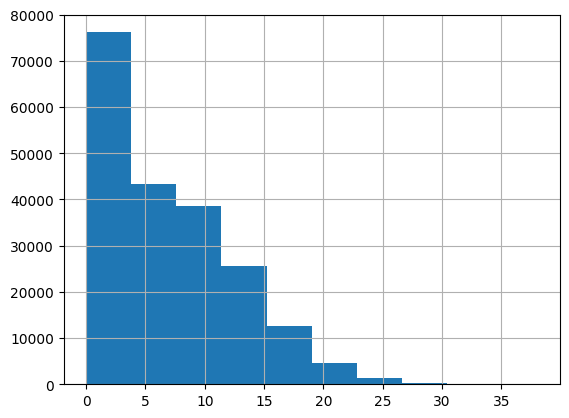

In [31]:
calls['duration'].hist();

In [32]:
sessions = pd.read_csv("C:\\Users\\HOME\\ya_datasets\\internet.csv")
sessions.head(5)

,Unnamed: 0,id,mb_used,session_date,user_id
0,0,1000_0,112.95,2018-11-25,1000
1,1,1000_1,1052.81,2018-09-07,1000
2,2,1000_2,1197.26,2018-06-25,1000
3,3,1000_3,550.27,2018-08-22,1000
4,4,1000_4,302.56,2018-09-24,1000


In [33]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Unnamed: 0    149396 non-null  int64  
 1   id            149396 non-null  object 
 2   mb_used       149396 non-null  float64
 3   session_date  149396 non-null  object 
 4   user_id       149396 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 5.7+ MB


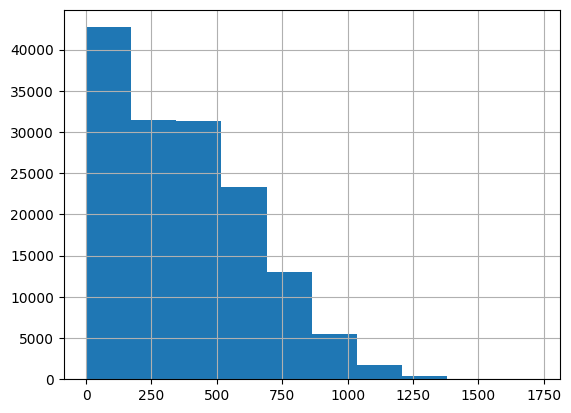

In [34]:
sessions['mb_used'].hist();

In [35]:
messages = pd.read_csv("C:\\Users\\HOME\\ya_datasets\\messages.csv")
messages.head(5)

,id,message_date,user_id
0,1000_0,2018-06-27,1000
1,1000_1,2018-10-08,1000
2,1000_2,2018-08-04,1000
3,1000_3,2018-06-16,1000
4,1000_4,2018-12-05,1000


In [36]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            123036 non-null  object
 1   message_date  123036 non-null  object
 2   user_id       123036 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 2.8+ MB


In [37]:
tariffs = pd.read_csv("C:\\Users\\HOME\\ya_datasets\\tariffs.csv")
tariffs.head(5)

,messages_included,mb_per_month_included,minutes_included,rub_monthly_fee,rub_per_gb,rub_per_message,rub_per_minute,tariff_name
0,50,15360,500,550,200,3,3,smart
1,1000,30720,3000,1950,150,1,1,ultra


In [38]:
tariffs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   messages_included      2 non-null      int64 
 1   mb_per_month_included  2 non-null      int64 
 2   minutes_included       2 non-null      int64 
 3   rub_monthly_fee        2 non-null      int64 
 4   rub_per_gb             2 non-null      int64 
 5   rub_per_message        2 non-null      int64 
 6   rub_per_minute         2 non-null      int64 
 7   tariff_name            2 non-null      object
dtypes: int64(7), object(1)
memory usage: 256.0+ bytes


In [39]:
users = pd.read_csv("C:\\Users\\HOME\\ya_datasets\\users.csv")
users.head(5)

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [40]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


## 2. Data Preprosessing

In [41]:
# Convert the reg_date column to datetime format
users['reg_date'] = pd.to_datetime(users['reg_date'])

# Convert the churn_date column to datetime format
users['churn_date'] = pd.to_datetime(users['churn_date'])

# Convert the call_date column to datetime format
calls['call_date'] = pd.to_datetime(calls['call_date'])

# Convert the message_date column to datetime format
messages['message_date'] = pd.to_datetime(messages['message_date'])

# Convert the session_date column to datetime format
sessions['session_date'] = pd.to_datetime(sessions['session_date'])

In [42]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     500 non-null    int64         
 1   age         500 non-null    int64         
 2   churn_date  38 non-null     datetime64[ns]
 3   city        500 non-null    object        
 4   first_name  500 non-null    object        
 5   last_name   500 non-null    object        
 6   reg_date    500 non-null    datetime64[ns]
 7   tariff      500 non-null    object        
dtypes: datetime64[ns](2), int64(2), object(4)
memory usage: 31.4+ KB


In [43]:
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         202607 non-null  object        
 1   call_date  202607 non-null  datetime64[ns]
 2   duration   202607 non-null  float64       
 3   user_id    202607 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 6.2+ MB


In [44]:
messages.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123036 entries, 0 to 123035
Data columns (total 3 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            123036 non-null  object        
 1   message_date  123036 non-null  datetime64[ns]
 2   user_id       123036 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 2.8+ MB


In [45]:
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Unnamed: 0    149396 non-null  int64         
 1   id            149396 non-null  object        
 2   mb_used       149396 non-null  float64       
 3   session_date  149396 non-null  datetime64[ns]
 4   user_id       149396 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 5.7+ MB


We convert the following columns to the `datetime` data type using the `to_datetime()` method:

- `reg_date` from the `users` table
- `churn_date` from the `users` table
- `call_date` from the `calls` table
- `message_date` from the `messages` table
- `session_date` from the `sessions` table

In [46]:
calls['duration'] = np.ceil(calls['duration']).astype('int')
calls.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202607 entries, 0 to 202606
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   id         202607 non-null  object        
 1   call_date  202607 non-null  datetime64[ns]
 2   duration   202607 non-null  int32         
 3   user_id    202607 non-null  int64         
dtypes: datetime64[ns](1), int32(1), int64(1), object(1)
memory usage: 5.4+ MB


We remove the `Unnamed: 0` column from the `sessions` dataframe. This column usually appears when a dataset is saved with an index included, for example with `df.to_csv(..., index=column)`. It is not needed for the analysis.

In [47]:
sessions = sessions.drop(columns='Unnamed: 0', axis=1)
sessions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149396 entries, 0 to 149395
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            149396 non-null  object        
 1   mb_used       149396 non-null  float64       
 2   session_date  149396 non-null  datetime64[ns]
 3   user_id       149396 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 4.6+ MB


We create a new `month` column in the `calls` dataframe by extracting the month number from the `call_date` column.

In [48]:
calls['month'] = calls['call_date'].dt.month
calls['month'].head(5)

0     7
1     8
2     6
3     9
4    12
Name: month, dtype: int64

We create a new `month` column in the `messages` dataframe by extracting the month number from the `message_date` column.

In [49]:
messages['month'] = messages['message_date'].dt.month
messages['month']

0          6
1         10
2          8
3          6
4         12
          ..
123031    12
123032     9
123033     9
123034    11
123035    11
Name: month, Length: 123036, dtype: int64

We create a new `month` column in the `sessions` dataframe by extracting the month number from the `session_date` column.

In [50]:
sessions['month'] = sessions['session_date'].dt.month
sessions['month']

0         11
1          9
2          6
3          8
4          9
          ..
149391    10
149392    12
149393    10
149394    11
149395    10
Name: month, Length: 149396, dtype: int64

We calculate the number of calls made by each user for each month and save the result in the `calls_per_month` variable.

In [51]:
calls_per_month = calls.groupby(['user_id', 'month'])['id'].count().reset_index()
calls_per_month = calls_per_month.rename(columns={'id': 'calls_count'})

In [53]:
calls_per_month.head(10)

,user_id,month,calls_count
0,1000,5,22
1,1000,6,43
2,1000,7,47
3,1000,8,52
4,1000,9,58
5,1000,10,57
6,1000,11,43
7,1000,12,46
8,1001,11,59
9,1001,12,63


We calculate the total number of call minutes used by each user for each month and save the result in the `minutes_per_month` variable.

To do this, we group the calls dataframe by two columns: user ID and month. Then we select the `duration` column and calculate the sum for each group.

In [55]:
minutes_per_month = calls.groupby(['user_id', 'month']).agg(minutes=('duration', 'sum'))

In [56]:
minutes_per_month.head(30)

minutes
user_id month         
1000    5          159
        6          172
        7          340
        8          408
        9          466
        10         350
        11         338
        12         333
1001    11         430
        12         414
1002    6          117
        7          214
        8          289
        9          206
        10         212
        11         243
        12         236
1003    8          380
        9          961
        10         855
        11         824
        12         802
1004    5           35
        6          171
        7          135
        8          137
        9          117
        10         145
        11         117
        12         130

We calculate the number of messages sent by each user for each month and save the result in the `messages_per_month` variable.

To do this, we group the messages dataframe by two columns: user ID and month. Then we select the `message_date` column and count the number of records for each group.

In [58]:
messages_per_month = messages.groupby(['user_id', 'month']).agg(messages=('message_date', 'count'))

In [59]:
messages_per_month.head(30)

messages
user_id month          
1000    5            22
        6            60
        7            75
        8            81
        9            57
        10           73
        11           58
        12           70
1002    6             4
        7            11
        8            13
        9             4
        10           10
        11           16
        12           12
1003    8            37
        9            91
        10           83
        11           94
        12           75
1004    5            95
        6           134
        7           181
        8           151
        9           146
        10          165
        11          158
        12          162
1005    1             7
        2            38

We calculate the total number of megabytes used by each user for each month and save the result in the `sessions_per_month` variable.

To do this, we group the internet sessions dataframe by two columns: user ID and month. Then we calculate the sum of `mb_used` for each group.

In [60]:
sessions_per_month = sessions.groupby(['user_id', 'month']).agg({'mb_used': 'sum'})
sessions_per_month

mb_used
user_id month          
1000    5       2253.49
        6      23233.77
        7      14003.64
        8      14055.93
        9      14568.91
...                 ...
1498    10     20579.36
1499    9       1845.75
        10     17788.51
        11     17963.31
        12     13055.58

[3203 rows x 1 columns]

## 3. Data Analysis and Revenue Calculation

We combine all previously calculated values into one dataframe called `user_behavior`.

For each `user_id` and `month` pair, the dataframe will contain information about the user's tariff, number of calls, number of messages, and amount of internet traffic used in megabytes.


In [65]:
users['churn_date'].count() / users['churn_date'].shape[0] * 100

7.6

We merge all monthly user-level tables into one dataframe. Since `user_id` and `month` are regular columns after `reset_index()`, we merge the tables by these columns instead of using indexes.

In [66]:
calls_per_month = calls.groupby(['user_id', 'month']).agg(calls=('duration', 'count')).reset_index()

minutes_per_month = calls.groupby(['user_id', 'month']).agg(minutes=('duration', 'sum')).reset_index()

messages_per_month = messages.groupby(['user_id', 'month']).agg(messages=('message_date', 'count')).reset_index()

sessions_per_month = sessions.groupby(['user_id', 'month']).agg(mb_used=('mb_used', 'sum')).reset_index()


In [69]:
user_behavior = (
    calls_per_month
    .merge(minutes_per_month, on=['user_id', 'month'], how='outer')
    .merge(messages_per_month, on=['user_id', 'month'], how='outer')
    .merge(sessions_per_month, on=['user_id', 'month'], how='outer')
    .merge(users, on='user_id', how='left')
)

user_behavior.head()

,user_id,month,calls,minutes,messages,mb_used,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,5,22.0,159.0,22.0,2253.49,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1000,6,43.0,172.0,60.0,23233.77,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
2,1000,7,47.0,340.0,75.0,14003.64,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
3,1000,8,52.0,408.0,81.0,14055.93,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
4,1000,9,58.0,466.0,57.0,14568.91,52,NaT,Краснодар,Рафаил,Верещагин,2018-05-25,ultra


In [68]:
sessions_per_month.columns

Index(['user_id', 'month', 'mb_used'], dtype='object')

In [70]:
user_behavior.isna().sum()

user_id          0
month            0
calls           40
minutes         40
messages       497
mb_used         11
age              0
churn_date    3027
city             0
first_name       0
last_name        0
reg_date         0
tariff           0
dtype: int64

In [71]:
user_behavior['calls'] = user_behavior['calls'].fillna(0)
user_behavior['minutes'] = user_behavior['minutes'].fillna(0)
user_behavior['messages'] = user_behavior['messages'].fillna(0)
user_behavior['mb_used'] = user_behavior['mb_used'].fillna(0)

In [72]:
tariffs = tariffs.rename(
    columns={
        'tariff_name': 'tariff'
    }
)

In [73]:
user_behavior = user_behavior.merge(tariffs, on='tariff')

We calculate the number of call minutes, messages, and megabytes that exceed the monthly limits included in each tariff.

In [74]:
user_behavior['paid_minutes'] = user_behavior['minutes'] - user_behavior['minutes_included']
user_behavior['paid_messages'] = user_behavior['messages'] - user_behavior['messages_included']
user_behavior['paid_mb'] = user_behavior['mb_used'] - user_behavior['mb_per_month_included']

for col in ['paid_messages', 'paid_minutes', 'paid_mb']:
    user_behavior.loc[user_behavior[col] < 0, col] = 0

We convert the internet traffic exceeding the tariff limit from megabytes to gigabytes and save the result in the `paid_gb` column.

In [75]:
user_behavior['paid_gb'] = np.ceil(user_behavior['paid_mb'] / 1024).astype(int)

We calculate the revenue from extra call minutes, extra messages, and extra internet traffic.

In [76]:
user_behavior['cost_minutes'] = user_behavior['paid_minutes'] * user_behavior['rub_per_minute']
user_behavior['cost_messages'] = user_behavior['paid_messages'] * user_behavior['rub_per_message']
user_behavior['cost_gb'] = user_behavior['paid_gb'] * user_behavior['rub_per_gb']

We calculate the monthly revenue for each user and store it in the `total_cost` column.

In [77]:
user_behavior['total_cost'] = \
      user_behavior['rub_monthly_fee']\
    + user_behavior['cost_minutes']\
    + user_behavior['cost_messages']\
    + user_behavior['cost_gb']

The `stats_df` dataframe will store the main statistics for each `month` and `tariff` pair.

In [80]:
# сохранение статистических метрик для каждой пары месяц-тариф
# в одной таблице stats_df (среднее значение, стандартное отклонение, медиана)

stats_df = user_behavior.pivot_table(
            index=['month', 'tariff'],\
            values=['calls', 'minutes', 'messages', 'mb_used'],\
            aggfunc=['mean', 'std', 'median']\
).round(2).reset_index()

stats_df.columns=['month', 'tariff', 'calls_mean', 'sessions_mean', 'messages_mean', 'minutes_mean',
                                     'calls_std',  'sessions_std', 'messages_std', 'minutes_std',
                                     'calls_median', 'sessions_median', 'messages_median',  'minutes_median']

stats_df.head(10)

,month,tariff,calls_mean,sessions_mean,messages_mean,minutes_mean,calls_std,sessions_std,messages_std,minutes_std,calls_median,sessions_median,messages_median,minutes_median
0,1,smart,27.68,8513.72,18.24,203.85,20.81,6444.68,16.20,154.23,20.5,7096.18,15.0,162.5
1,1,ultra,59.44,13140.68,33.78,428.11,41.64,6865.35,30.67,269.76,51.0,14791.37,32.0,382.0
2,2,smart,40.19,11597.05,24.09,298.69,25.39,6247.35,21.75,190.82,38.5,12553.71,20.0,258.0
3,2,ultra,41.54,11775.94,21.96,297.12,40.97,10644.64,26.77,296.51,25.0,7327.12,5.5,168.0
4,3,smart,54.32,15104.16,31.86,390.05,25.54,5828.24,26.80,191.89,59.0,15670.25,23.0,409.0
5,3,ultra,67.68,17535.55,32.30,489.65,44.84,10951.79,41.62,333.74,57.0,17495.18,20.0,403.0
6,4,smart,51.31,13462.18,30.74,367.13,25.70,5698.25,24.54,186.49,52.0,14087.65,28.0,368.5
7,4,ultra,64.09,16828.13,31.56,458.02,36.27,9718.65,37.51,267.68,61.0,16645.78,17.0,453.0
8,5,smart,55.24,15805.18,33.77,387.36,25.38,5978.23,27.04,186.60,59.0,16323.94,30.0,433.0
9,5,ultra,72.51,19363.15,37.85,510.33,41.08,10046.11,40.31,289.60,75.0,18696.43,25.0,519.0


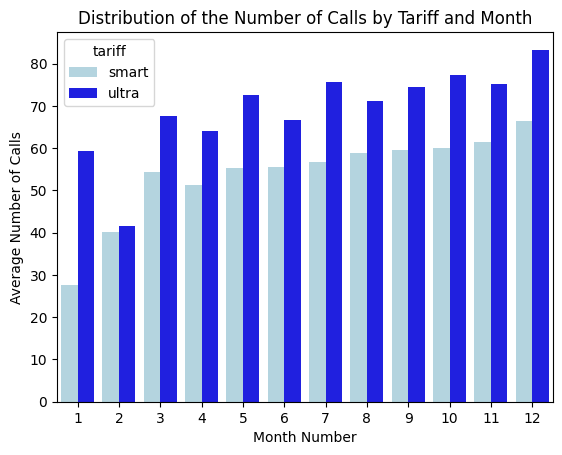

In [81]:
ax = sns.barplot(
    x='month',
    y='calls_mean',
    hue='tariff',
    data=stats_df,
    palette=['lightblue', 'blue']
)

ax.set_title('Distribution of the Number of Calls by Tariff and Month')
ax.set(xlabel='Month Number', ylabel='Average Number of Calls');

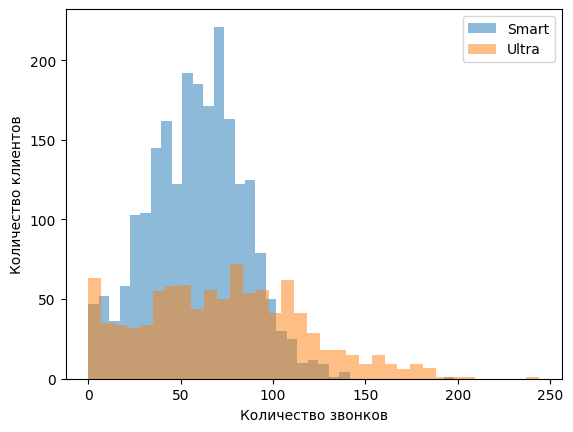

In [82]:
user_behavior.groupby('tariff')['calls'].plot(kind='hist', bins=35, alpha=0.5)
plt.legend(['Smart', 'Ultra'])
plt.xlabel('Количество звонков')
plt.ylabel('Количество клиентов')
plt.show()

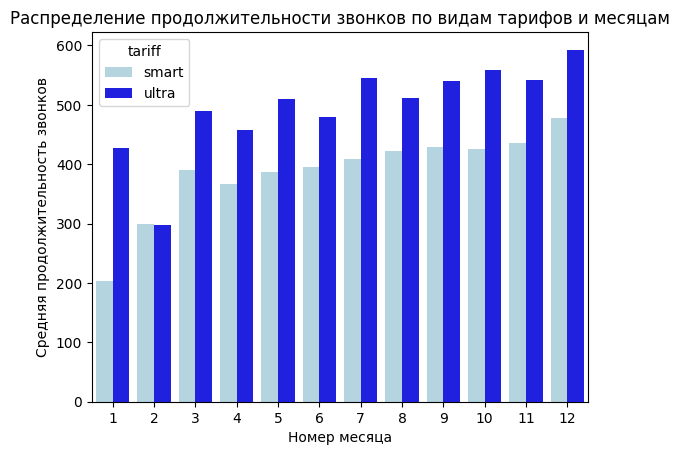

In [83]:
ax = sns.barplot(x='month',
            y='minutes_mean',
            hue="tariff",
            data=stats_df,
            palette=['lightblue', 'blue'])

ax.set_title('Распределение продолжительности звонков по видам тарифов и месяцам')
ax.set(xlabel='Номер месяца', ylabel='Средняя продолжительность звонков');

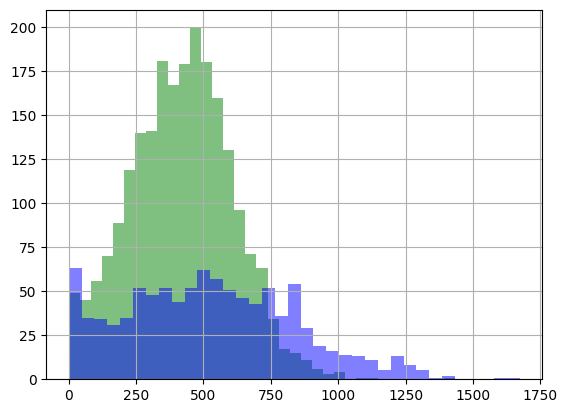

In [84]:
user_behavior[user_behavior['tariff'] =='smart']['minutes'].hist(bins=35, alpha=0.5, color='green')
user_behavior[user_behavior['tariff'] =='ultra']['minutes'].hist(bins=35, alpha=0.5, color='blue');

**Conclusition:** The average call duration is higher among `Ultra` tariff users than among `Smart` tariff users.

During the year, users of both tariffs increase their average call duration. For `Smart` users, this growth is relatively steady throughout the year. In contrast, `Ultra` users do not show the same linear stability.

It is also worth noting that February had the lowest average call duration for users of both tariff plans.

Next, we analyze the distribution of the average number of messages by tariff and month.


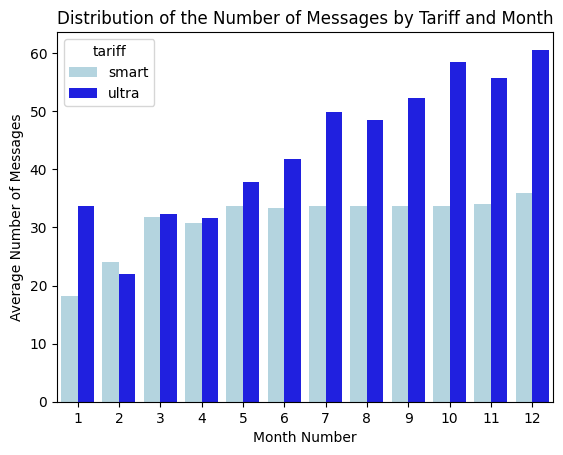

In [86]:
ax = sns.barplot(
    x='month',
    y='messages_mean',
    hue='tariff',
    data=stats_df,
    palette=['lightblue', 'blue']
)

ax.set_title('Distribution of the Number of Messages by Tariff and Month')
ax.set(xlabel='Month Number', ylabel='Average Number of Messages');


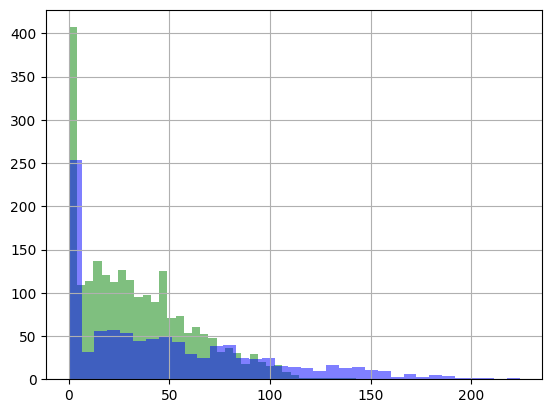

In [85]:
user_behavior[user_behavior['tariff'] =='smart']['messages'].hist(bins=35, alpha=0.5, color='green')
user_behavior[user_behavior['tariff'] =='ultra']['messages'].hist(bins=35, alpha=0.5, color='blue');

**Conclusion:** On average, `Ultra` tariff users send more messages than `Smart` tariff users, by almost 20 messages.

The number of messages increases during the year for both tariffs. The trend in messaging activity is similar to the trend in call duration: February shows the lowest number of messages, while `Ultra` users again demonstrate positive but non-linear growth over time.


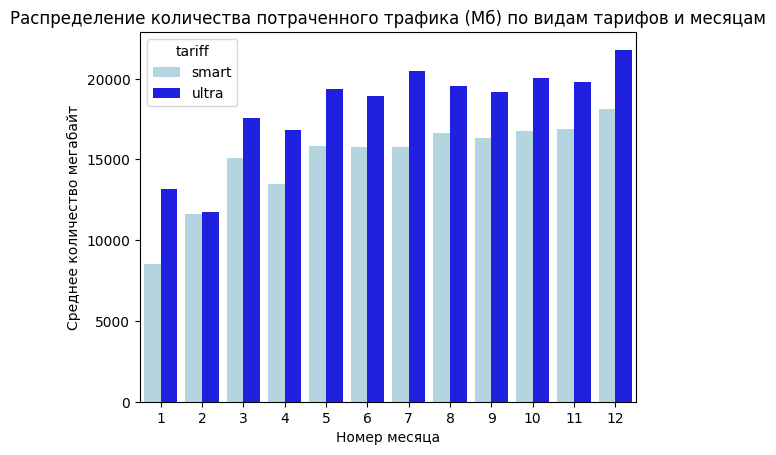

In [87]:
ax = sns.barplot(x='month',
            y='sessions_mean',
            hue="tariff",
            data=stats_df,
            palette=['lightblue', 'blue']
)

ax.set_title('Распределение количества потраченного трафика (Мб) по видам тарифов и месяцам')
ax.set(xlabel='Номер месяца', ylabel='Среднее количество мегабайт');

**Comparison of Internet Traffic Usage Between Smart and Ultra Users**


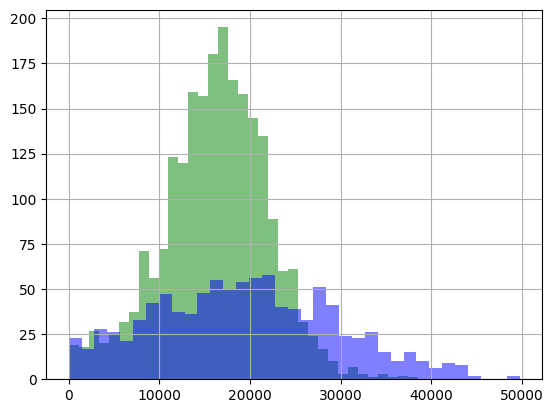

In [89]:
user_behavior[user_behavior['tariff'] =='smart']['mb_used'].hist(bins=35, alpha=0.5, color='green')
user_behavior[user_behavior['tariff'] =='ultra']['mb_used'].hist(bins=35, alpha=0.5, color='blue');

**Conclusion:** Users consumed the least amount of internet traffic in January, February, and April.

Most often, `Smart` tariff users spend around 15–17 GB per month, while `Ultra` tariff users typically use around 19–21 GB per month.


## 4. Hypothesis Testing

### Hypothesis 1: We test whether the average revenue from users of the `Ultra` and `Smart` tariffs is different.

```text
H_0: The average revenue (`total_cost`) of Ultra users is equal to the average revenue of Smart users.
H_a: The average revenue (`total_cost`) of Ultra users is not equal to the average revenue of Smart users.

alpha = 0.05

In [94]:
alpha = 0.05

ultra = user_behavior[user_behavior['tariff'] == 'ultra']
smart = user_behavior[user_behavior['tariff'] == 'smart']
# smart = user_behavior.query('tariff == "smart"')

results = st.ttest_ind(
    ultra['total_cost'],
    smart['total_cost'],
    equal_var=False
)

print(results.pvalue)

if results.pvalue < alpha:
    print('Hypothesis 1: We reject the null hypothesis')
else:
    print('Hypothesis 1: We fail to reject the null hypothesis')

4.2606313931076085e-250
Hypothesis 1: We reject the null hypothesis


### Hypothesis 2: Average Revenue Differs Between Moscow Users and Users From Other Cities

We test whether the average revenue from users in Moscow differs from the average revenue from users in other cities.

```text
H_0: The average revenue (`total_cost`) of users from Moscow is equal to the average revenue of users from other cities.
H_1: The average revenue (`total_cost`) of users from Moscow is not equal to the average revenue of users from other cities.

alpha = 0.05

In [95]:
moscow = user_behavior[user_behavior['city'] == 'Москва']
region = user_behavior[user_behavior['city'] != 'Москва']

results = st.ttest_ind(
    moscow['total_cost'],
    region['total_cost'],
    equal_var=False
)

alpha = 0.05

print(results.pvalue)

if results.pvalue < alpha:
    print('Hypothesis 2: We reject the null hypothesis')
else:
    print('Hypothesis 2: We fail to reject the null hypothesis')

0.5257376663729298
Hypothesis 2: We fail to reject the null hypothesis


### Conclusion

The p-value is `0.5257`, which is higher than the selected significance level `alpha = 0.05`.

Therefore, we fail to reject the null hypothesis. Based on the available data, there is no statistically significant evidence that the average revenue differs between the compared user groups.

In other words, the observed difference in average revenue may be due to random variation rather than a real difference between the groups.